# Laboratorio ENEIC Notebook 03: Pipeline de regresión lineal

Este notebook cubre el **punto 5** del laboratorio. Lee exclusivamente el Parquet de 2025 generado por `01_carga_calidad.ipynb`.

* **Objetivo:** `salario_mensual` en quetzales, sin transformaciones ni recortes de valores extremos.
* **Predictores (exactamente seis):** `edad`, `antiguedad`, `horas_semanales`, `nivel_educativo`, `categoria_ocupacional` y `dominio`.
* **Entrenamiento:** I, II y III de 2025. **Validación:** IV de 2025. Es la asignación de la tabla del enunciado.
* **Prueba:** I de 2026 queda reservado para el punto 7; este notebook no lo lee.
* Todas las etapas del pipeline (indexadores, codificador y modelo) se ajustan **solo** con el conjunto de entrenamiento.
* Los modelos y las métricas son **no ponderados**.

## 0. Preparación

In [1]:
import os, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pyspark
from pyspark.sql import SparkSession, functions as F
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

spark = (
    SparkSession.builder
    .appName("Lab ENEIC - 03 Regresion lineal")
    .master("local[*]")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("Spark:", spark.version)

BASE_DIR  = Path(os.environ.get("LAB_BASE_DIR", "/opt/app"))
OUT_DIR   = BASE_DIR / "working_dir" / "eneic_parquet"
MODEL_DIR = OUT_DIR / "modelos"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
SEED = 42
def q(x):
    return f"−Q{abs(x):,.0f}" if x < 0 else f"Q{x:,.0f}"
fmt_q = mtick.FuncFormatter(lambda x, _: q(x))
COLOR_REF, COLOR_LR = "#8a8984", "#2a78d6"

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/26 21:20:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 3.5.1


### 0.1 Variables del modelo

Se definen una sola vez y se reutilizan en todo el notebook. `NUM_HOGAR`, `NUM_PERSONA` y `periodo_archivo` se conservan **solo** para auditoría y para el análisis de personas repetidas; no entran al vector de predictores. Tampoco entran `FACTOR`, la etiqueta de cluster ni ningún otro monto de ingreso.

In [2]:
OBJETIVO    = "salario_mensual"
NUMERICAS   = ["edad", "antiguedad", "horas_semanales"]
CATEGORICAS = ["nivel_educativo", "categoria_ocupacional", "dominio"]
PREDICTORES = NUMERICAS + CATEGORICAS
AUDITORIA   = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]
DESCRIPCION = ["nivel_educativo_desc", "categoria_ocupacional_desc", "dominio_desc"]

PERIODOS_TRAIN = ["2025T1", "2025T2", "2025T3"]
PERIODO_VALID  = "2025T4"
assert len(PREDICTORES) == 6

## 1. Conjuntos de entrenamiento y validación

La partición es **temporal** y sigue la tabla del enunciado: los tres primeros trimestres de 2025 para entrenar y el cuarto para validar. Se prefiere a una partición aleatoria de filas por dos razones:

1. **Imita el uso final.** En el punto 7 se entrenará con 2025 y se predecirá un trimestre posterior (I de 2026). Validar con IV de 2025 reproduce esa situación: el modelo nunca ve el trimestre que se evalúa.
2. **Reduce la fuga por el panel rotativo.** Una partición aleatoria de filas pondría las observaciones de una misma persona en distintos trimestres a ambos lados de la partición con mucha frecuencia. Con la partición temporal esto no desaparece del todo (la ENEIC vuelve a entrevistar hogares), así que en la sección 1.1 se mide cuántos registros de validación corresponden a personas ya vistas en entrenamiento.

In [3]:
df = spark.read.parquet(str(OUT_DIR / "eneic_2025_preparado.parquet"))
columnas = AUDITORIA + PREDICTORES + DESCRIPCION + [OBJETIVO]

train = df.filter(F.col("periodo_archivo").isin(PERIODOS_TRAIN)).select(*columnas).cache()
valid = df.filter(F.col("periodo_archivo") == PERIODO_VALID).select(*columnas)

# Controles: sin nulos en predictores ni objetivo; objetivo estrictamente positivo
for nombre, d in [("train", train), ("valid", valid)]:
    nulos = d.select([F.sum(F.col(c).isNull().cast("int")).alias(c) for c in PREDICTORES + [OBJETIVO]]).first().asDict()
    assert sum(nulos.values()) == 0, (nombre, nulos)
    assert d.filter(F.col(OBJETIVO) <= 0).count() == 0

def resumen_objetivo(d):
    return d.agg(
        F.count("*").alias("n"), F.mean(OBJETIVO).alias("media"),
        F.expr(f"percentile({OBJETIVO}, 0.5)").alias("mediana"), F.stddev(OBJETIVO).alias("desv_est"),
        F.expr(f"percentile({OBJETIVO}, 0.95)").alias("p95"), F.expr(f"percentile({OBJETIVO}, 0.99)").alias("p99"),
        F.max(OBJETIVO).alias("max"),
    ).toPandas().iloc[0]

print("Registros por período y conjunto:")
display(df.groupBy("periodo_archivo").count().orderBy("periodo_archivo").toPandas()
          .assign(conjunto=lambda t: np.where(t.periodo_archivo.isin(PERIODOS_TRAIN), "entrenamiento",
                                              np.where(t.periodo_archivo == PERIODO_VALID, "validación", "-"))))
display(pd.DataFrame({"entrenamiento (2025T1-T3)": resumen_objetivo(train),
                      "validación (2025T4)": resumen_objetivo(valid)}).T.round(1))

Registros por período y conjunto:


,periodo_archivo,count,conjunto
0,2025T1,13419,entrenamiento
1,2025T2,13492,entrenamiento
2,2025T3,13450,entrenamiento
3,2025T4,12664,validación


,n,media,mediana,desv_est,p95,p99,max
entrenamiento (2025T1-T3),40361.0,3383.1,3000.0,2906.4,8000.0,15000.0,99000.0
validación (2025T4),12664.0,3544.6,3200.0,2885.2,8000.0,15000.0,60000.0


**Interpretación.** Entrenamiento tiene 40,361 registros (76 %) y validación 12,664 (24 %). La distribución del objetivo es parecida en ambos conjuntos: desviación estándar cercana a Q2,900, p95 = Q8,000 y p99 = Q15,000 en los dos. Aun así, IV de 2025 tiene un nivel algo mayor: la mediana sube de Q3,000 a Q3,200 y la media de Q3,383 a Q3,545. Es el mismo aumento observado en el notebook 02, que coincide con una menor proporción de jornaleros en la segunda mitad del año. Por eso, un modelo que solo reproduzca el nivel promedio de entrenamiento tenderá a subestimar ligeramente en validación. El salario máximo de entrenamiento (Q99,000) no tiene equivalente en validación, cuyo máximo es Q60,000.

### 1.1 Personas de validación que también aparecen en entrenamiento

En el notebook 01 se comprobó que `NUM_HOGAR` + `NUM_PERSONA` identifica a la misma persona entre trimestres. Se marca cada registro de validación según si esa persona ya fue observada en I–III de 2025. Esta marca **no** es un predictor; solo se usa para evaluar después si el error cambia entre personas conocidas y nuevas.

In [4]:
personas_train = train.select("NUM_HOGAR", "NUM_PERSONA").distinct().withColumn("_vista", F.lit(True))
valid = (valid.join(personas_train, ["NUM_HOGAR", "NUM_PERSONA"], "left")
              .withColumn("persona_en_train", F.coalesce(F.col("_vista"), F.lit(False)))
              .drop("_vista")
              .cache())

N_TRAIN, N_VALID = train.count(), valid.count()
solap = valid.groupBy("persona_en_train").count().toPandas()
solap["pct"] = (100 * solap["count"] / N_VALID).round(1)
print(f"Entrenamiento: {N_TRAIN:,} registros | Validación: {N_VALID:,} registros")
display(solap)

Entrenamiento: 40,361 registros | Validación: 12,664 registros


,persona_en_train,count,pct
0,True,8831,69.7
1,False,3833,30.3


**Interpretación.** El **69.7 %** de los registros de validación (8,831) corresponde a personas que ya aparecen en I–III de 2025; solo el 30.3 % (3,833) son personas nuevas. Es la consecuencia esperada del panel rotativo: la partición temporal impide que un mismo registro persona-trimestre esté en ambos conjuntos, pero no que la misma persona aparezca en los dos.

Esto no es una fuga del objetivo, porque el salario de IV de 2025 nunca se usa para entrenar. Sin embargo, un modelo muy flexible podría “reconocer” la combinación de predictores de una persona y acertar su salario porque lo vio en otro trimestre. Por eso, en la sección 6 se compara el error entre personas vistas y nuevas. Es probable que en I de 2026 ocurra algo similar, porque también comparte hogares con 2025.

## 2. Modelo de referencia

Antes de ajustar la regresión se necesita un punto de comparación que **no use ningún predictor**. El modelo de referencia predice para todas las personas un valor constante calculado con el conjunto de entrenamiento:

* **Media de entrenamiento:** es la constante que minimiza el error cuadrático; su R² en validación es cercano a 0 por definición. Es la referencia principal para RMSE y R².
* **Mediana de entrenamiento:** es la constante que minimiza el error absoluto, así que es una referencia más exigente para el MAE.

Las tres métricas se calculan con `RegressionEvaluator` sobre **todos** los registros del conjunto correspondiente. El residuo se define como `real − predicho`: positivo indica subestimación y negativo, sobreestimación.

In [5]:
METRICAS = ["mae", "rmse", "r2"]
EVALUADORES = {m: RegressionEvaluator(labelCol=OBJETIVO, predictionCol="prediction", metricName=m) for m in METRICAS}

def evaluar(pred):
    return {m: EVALUADORES[m].evaluate(pred) for m in METRICAS}

media_train, mediana_train = train.agg(F.mean(OBJETIVO), F.expr(f"percentile({OBJETIVO}, 0.5)")).first()

def predecir_constante(d, valor):
    return d.withColumn("prediction", F.lit(float(valor)))

referencias = {}
for nombre, valor in [("Referencia: media de entrenamiento", media_train),
                      ("Referencia: mediana de entrenamiento", mediana_train)]:
    referencias[nombre] = {
        "valor_predicho": valor,
        **{f"{m}_train": v for m, v in evaluar(predecir_constante(train, valor)).items()},
        **{f"{m}_valid": v for m, v in evaluar(predecir_constante(valid, valor)).items()},
    }
tabla_ref = pd.DataFrame(referencias).T
display(tabla_ref.round(4))

,valor_predicho,mae_train,rmse_train,r2_train,mae_valid,rmse_valid,r2_valid
Referencia: media de entrenamiento,3383.125,1696.3062,2906.3319,0.0000,1672.5026,2889.5714,-0.0031
Referencia: mediana de entrenamiento,3000.000,1676.4102,2931.4757,-0.0174,1670.3902,2936.0039,-0.0356


**Interpretación.** El modelo de referencia muestra el tamaño del error cuando no se usa ninguna característica de la persona. Si se predice Q3,383 (la media de entrenamiento) para todos, el error absoluto medio en validación es de **Q1,673** y el RMSE de **Q2,890**, prácticamente igual a la desviación estándar del salario. Su R² es −0.003: es ligeramente negativo porque la media de validación (Q3,545) es mayor que la de entrenamiento.

La mediana (Q3,000) reduce el MAE apenas a Q1,670, pero empeora el RMSE (Q2,936) y el R² (−0.036): cada constante es óptima para una métrica distinta. Un modelo útil debe mejorar claramente estos valores. Además, que el RMSE sea casi el doble del MAE anticipa el peso de los errores grandes: unos pocos salarios muy altos elevan mucho el error cuadrático.

## 3. Pipeline de regresión lineal

| Etapa | Componente | Detalle |
|---|---|---|
| a | `StringIndexer` (×3) | `nivel_educativo`, `categoria_ocupacional`, `dominio` → índices. `handleInvalid="keep"`: una categoría que no exista en entrenamiento (por ejemplo `DESCONOCIDO`) no detiene la predicción. |
| a | `OneHotEncoder` | Índices → vectores binarios (una columna por categoría). |
| b | `VectorAssembler` | `edad`, `antiguedad`, `horas_semanales` + las tres variables codificadas → `features`. |
| c | Estandarización | Opción interna `standardization=True` de `LinearRegression`: escala cada predictor por su desviación estándar **dentro del optimizador**. Así la penalización trata igual a todas las variables y los coeficientes se devuelven en las unidades originales (quetzales por año, por hora o por categoría), lo que facilita interpretarlos. No se usa además `StandardScaler`. |
| d | `LinearRegression` | Objetivo `salario_mensual` en quetzales. |

Todas las etapas se ajustan con `pipeline.fit(train)`: los catálogos de categorías, las desviaciones estándar para escalar y los coeficientes salen únicamente de I–III de 2025.

In [6]:
def etapas_preparacion():
    indexadores = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in CATEGORICAS]
    codificador = OneHotEncoder(inputCols=[f"{c}_idx" for c in CATEGORICAS],
                                outputCols=[f"{c}_ohe" for c in CATEGORICAS])
    ensamblador = VectorAssembler(inputCols=NUMERICAS + [f"{c}_ohe" for c in CATEGORICAS], outputCol="features")
    return indexadores + [codificador, ensamblador]

def pipeline_lr(regParam, elasticNetParam):
    lr = LinearRegression(featuresCol="features", labelCol=OBJETIVO, predictionCol="prediction",
                          standardization=True, fitIntercept=True, maxIter=200,
                          regParam=regParam, elasticNetParam=elasticNetParam)
    return Pipeline(stages=etapas_preparacion() + [lr])

# Vista del vector de predictores que produce la parte de preparación (ajustada con train)
prep_modelo = Pipeline(stages=etapas_preparacion()).fit(train)
atributos = prep_modelo.transform(train.limit(1)).schema["features"].metadata["ml_attr"]["attrs"]
NOMBRES_FEATURES = [a["name"] for a in sorted(sum(atributos.values(), []), key=lambda a: a["idx"])]
print(f"Dimensión del vector de predictores: {len(NOMBRES_FEATURES)}")
for i, idx_model in enumerate(prep_modelo.stages[:3]):
    print(f"  {CATEGORICAS[i]:<22} categorías aprendidas (orden de índice): {idx_model.labels}")
print(NOMBRES_FEATURES)

Dimensión del vector de predictores: 18
  nivel_educativo        categorías aprendidas (orden de índice): ['4', '2', '3', '5', '0', '6', '1', '7']
  categoria_ocupacional  categorías aprendidas (orden de índice): ['2', '3', '1', '4']
  dominio                categorías aprendidas (orden de índice): ['1', '2', '3']
['edad', 'antiguedad', 'horas_semanales', 'nivel_educativo_ohe_4', 'nivel_educativo_ohe_2', 'nivel_educativo_ohe_3', 'nivel_educativo_ohe_5', 'nivel_educativo_ohe_0', 'nivel_educativo_ohe_6', 'nivel_educativo_ohe_1', 'nivel_educativo_ohe_7', 'categoria_ocupacional_ohe_2', 'categoria_ocupacional_ohe_3', 'categoria_ocupacional_ohe_1', 'categoria_ocupacional_ohe_4', 'dominio_ohe_1', 'dominio_ohe_2', 'dominio_ohe_3']


**Lectura del vector.** El vector tiene 18 columnas: 3 numéricas, 8 niveles educativos, 4 categorías ocupacionales y 3 dominios. Los `StringIndexer` ordenan las categorías por frecuencia en entrenamiento; por eso el índice 0 corresponde a diversificado, empresa privada y urbano metropolitano.

**Detalle técnico: no hay categoría omitida.** Con `handleInvalid="keep"`, el indexador reserva una posición extra para categorías no vistas, y el `OneHotEncoder` (con `dropLast=True`, su valor por defecto) elimina justamente esa posición. Así, **cada categoría observada conserva su columna**. Las columnas de cada variable categórica suman 1 en todas las filas, igual que el intercepto, lo que produce colinealidad perfecta (la “trampa de las variables ficticias”). Esto tiene tres consecuencias:

* Las **predicciones** siguen bien definidas; lo que deja de ser único es el valor individual de cada coeficiente categórico. En la sección 5.1 se expresan como diferencias respecto a una categoría de referencia, que sí son únicas.
* Sin regularización (λ = 0), Spark no puede usar la solución directa de las ecuaciones normales (Cholesky), porque la matriz es singular, y recurre al optimizador iterativo L-BFGS. Por eso esa configuración reporta iteraciones y Ridge no. Con λ > 0, la penalización hace que la solución sea única.
* Una categoría nueva en la prueba (por ejemplo `DESCONOCIDO`) se codificaría con ceros en esa variable, sin detener el pipeline.

## 4. Configuraciones de regularización

`LinearRegression` de Spark minimiza el error cuadrático medio más una penalización *elastic net*:

$$\frac{1}{2n}\sum_i (y_i-\hat y_i)^2 + \lambda\left[\alpha\,\lVert w\rVert_1 + \frac{1-\alpha}{2}\lVert w\rVert_2^2\right]$$

* `regParam` = λ controla la **intensidad** de la penalización.
* `elasticNetParam` = α controla el **tipo**: 0 = Ridge (L2, encoge los coeficientes), 1 = Lasso (L1, puede llevar coeficientes exactamente a cero), 0.5 = mezcla.

Se prueban 13 configuraciones: una sin regularización (λ = 0, mínimos cuadrados ordinarios) y λ ∈ {1, 10, 100, 1000} combinada con α ∈ {0, 0.5, 1}. Cada pipeline completo se ajusta con entrenamiento y se evalúa en entrenamiento y validación. La configuración elegida es la de **menor RMSE de validación**.

In [7]:
CONFIGS_LR = [{"regParam": 0.0, "elasticNetParam": 0.0}] + [
    {"regParam": lam, "elasticNetParam": alpha} for lam in [1.0, 10.0, 100.0, 1000.0] for alpha in [0.0, 0.5, 1.0]
]

resultados, modelos = [], {}
for i, cfg in enumerate(CONFIGS_LR):
    t0 = time.time()
    modelo = pipeline_lr(**cfg).fit(train)
    segundos = time.time() - t0
    lr_m = modelo.stages[-1]
    m_train = evaluar(modelo.transform(train))
    m_valid = evaluar(modelo.transform(valid))
    modelos[i] = modelo
    resultados.append({
        "config": i, **cfg,
        **{f"{m}_train": v for m, v in m_train.items()},
        **{f"{m}_valid": v for m, v in m_valid.items()},
        "coef_no_cero": int(np.sum(np.abs(lr_m.coefficients.toArray()) > 1e-9)),
        "iteraciones": lr_m.summary.totalIterations,
        "segundos": round(segundos, 1),
    })

res_lr = pd.DataFrame(resultados)
res_lr.to_csv(OUT_DIR / "lr_configuraciones_validacion.csv", index=False)
display(res_lr.sort_values("rmse_valid").round(4))

,config,regParam,elasticNetParam,mae_train,rmse_train,r2_train,mae_valid,rmse_valid,r2_valid,coef_no_cero,iteraciones,segundos
0,0,0.0,0.0,1237.7905,2245.2927,0.4032,1210.1375,2186.4196,0.4257,18,13,3.6
1,1,1.0,0.0,1237.7521,2245.2927,0.4032,1210.0902,2186.4324,0.4257,18,0,1.3
2,2,1.0,0.5,1237.5560,2245.2937,0.4032,1209.8529,2186.4698,0.4256,18,37,1.0
3,3,1.0,1.0,1237.4406,2245.2949,0.4032,1209.7018,2186.5019,0.4256,17,200,0.9
4,4,10.0,0.0,1237.4116,2245.2969,0.4032,1209.6705,2186.5514,0.4256,18,0,0.9
5,5,10.0,0.5,1235.9358,2245.3627,0.4031,1207.8016,2186.8920,0.4254,15,169,0.9
6,6,10.0,1.0,1234.6699,2245.5124,0.4030,1206.1842,2187.2907,0.4252,15,72,0.9
7,7,100.0,0.0,1234.3589,2245.6919,0.4030,1205.9311,2188.0623,0.4248,18,0,0.8
8,8,100.0,0.5,1226.8840,2251.9879,0.3996,1195.8023,2197.0191,0.4201,13,34,0.9
9,9,100.0,1.0,1229.9735,2265.4652,0.3924,1197.9532,2213.1016,0.4116,13,28,0.8


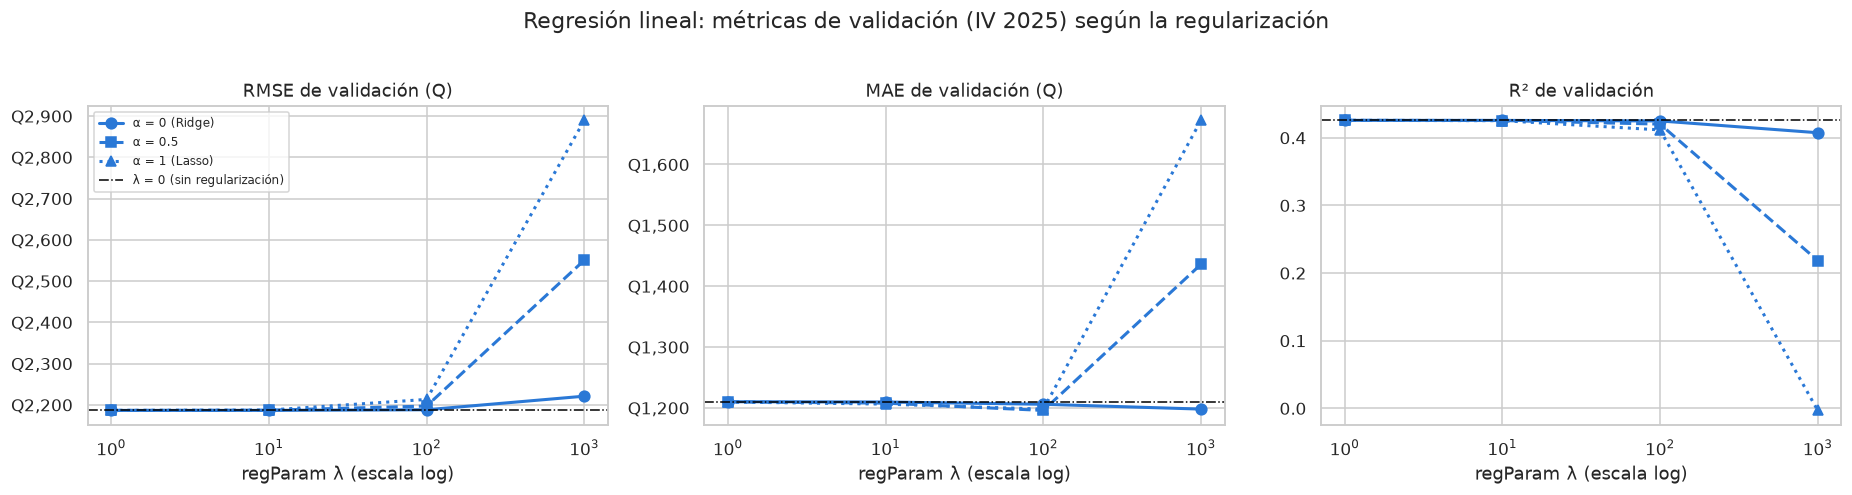

Referencia (media de entrenamiento) en validación: RMSE = Q2,889.6 | MAE = Q1,672.5 | R² = -0.0031


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
ols = res_lr[res_lr.regParam == 0].iloc[0]
ref_media = tabla_ref.loc["Referencia: media de entrenamiento"]
estilos = {0.0: ("o", "-"), 0.5: ("s", "--"), 1.0: ("^", ":")}
for ax, m, titulo in [(axes[0], "rmse_valid", "RMSE de validación (Q)"),
                      (axes[1], "mae_valid", "MAE de validación (Q)"),
                      (axes[2], "r2_valid", "R² de validación")]:
    for alpha, g in res_lr[res_lr.regParam > 0].groupby("elasticNetParam"):
        mk, ls = estilos[alpha]
        ax.plot(g["regParam"], g[m], marker=mk, ls=ls, lw=2, ms=7, color=COLOR_LR,
                label=f"α = {alpha:g}" + (" (Ridge)" if alpha == 0 else " (Lasso)" if alpha == 1 else ""))
    ax.axhline(ols[m], color="black", lw=1, ls="-.", label="λ = 0 (sin regularización)")
    ax.set_xscale("log"); ax.set_xlabel("regParam λ (escala log)"); ax.set_title(titulo)
    if m != "r2_valid":
        ax.yaxis.set_major_formatter(fmt_q)
axes[0].legend(fontsize=8)
fig.suptitle("Regresión lineal: métricas de validación (IV 2025) según la regularización", y=1.02)
plt.tight_layout(); plt.show()
print(f"Referencia (media de entrenamiento) en validación: RMSE = Q{ref_media.rmse_valid:,.1f} | "
      f"MAE = Q{ref_media.mae_valid:,.1f} | R² = {ref_media.r2_valid:.4f}")

**Interpretación.**

* **La regularización no mejora la validación.** El menor RMSE se obtiene sin penalización (λ = 0: Q2,186.42), y Ridge con λ = 1 y 10 queda prácticamente igual (Q2,186.43–2,186.55): la diferencia es de centavos. Es lo esperable, porque hay 40,361 registros para estimar solo 18 coeficientes. El modelo sin penalizar no tiene varianza que controlar ni sobreajusta: su R² de entrenamiento (0.403) es incluso menor que el de validación (0.426).
* **Con penalizaciones grandes el modelo empeora**, porque encoge los coeficientes hacia cero y las predicciones hacia la media. Con λ = 1000, Ridge baja el R² a 0.407; elastic net (α = 0.5) conserva solo 6 coeficientes y baja a 0.218; y Lasso (α = 1) anula los 18 coeficientes, por lo que reproduce exactamente al modelo de referencia (RMSE Q2,889.57, R² −0.003).
* **El MAE y el RMSE no eligen lo mismo.** Elastic net y Lasso con λ = 100 bajan el MAE hasta Q1,196–1,198 (frente a Q1,210 sin penalización), aunque suben el RMSE. Al encoger los coeficientes de los niveles educativos altos, reducen las predicciones altas: mejoran ligeramente la mayoría de salarios bajos y medios, pero empeoran los pocos salarios altos, que pesan mucho más en el RMSE. Aquí se aplica el criterio del enunciado (menor RMSE de validación).
* La configuración Lasso con λ = 1 alcanzó el límite de 200 iteraciones; su resultado es prácticamente igual al de las demás con λ pequeño, así que no afecta la elección.

## 5. Configuración seleccionada y comparación con la referencia

In [9]:
mejor = res_lr.sort_values(["rmse_valid", "regParam"]).iloc[0]
MEJOR_CFG = {"regParam": float(mejor.regParam), "elasticNetParam": float(mejor.elasticNetParam)}
modelo_lr = modelos[int(mejor.config)]
print("Configuración seleccionada (menor RMSE de validación):", MEJOR_CFG)

pred_valid_lr = modelo_lr.transform(valid).withColumn("residuo", F.col(OBJETIVO) - F.col("prediction")).cache()

comparacion = pd.DataFrame({
    "Referencia: media de entrenamiento":   tabla_ref.loc["Referencia: media de entrenamiento", ["mae_valid", "rmse_valid", "r2_valid"]].values,
    "Referencia: mediana de entrenamiento": tabla_ref.loc["Referencia: mediana de entrenamiento", ["mae_valid", "rmse_valid", "r2_valid"]].values,
    f"Regresión lineal (λ={MEJOR_CFG['regParam']:g}, α={MEJOR_CFG['elasticNetParam']:g})": mejor[["mae_valid", "rmse_valid", "r2_valid"]].values,
}, index=["MAE", "RMSE", "R²"]).T.astype(float)
ref = comparacion.iloc[0]
comparacion["MAE vs media (%)"]  = 100 * (comparacion["MAE"] / ref["MAE"] - 1)
comparacion["RMSE vs media (%)"] = 100 * (comparacion["RMSE"] / ref["RMSE"] - 1)
print(f"Métricas en validación (IV 2025, n = {N_VALID:,}):")
display(comparacion.round(3))

print("Entrenamiento vs validación del modelo elegido:")
display(pd.DataFrame({"entrenamiento": mejor[["mae_train", "rmse_train", "r2_train"]].values,
                      "validación": mejor[["mae_valid", "rmse_valid", "r2_valid"]].values},
                     index=["MAE", "RMSE", "R²"]).astype(float).round(3))

Configuración seleccionada (menor RMSE de validación): {'regParam': 0.0, 'elasticNetParam': 0.0}
Métricas en validación (IV 2025, n = 12,664):


,MAE,RMSE,R²,MAE vs media (%),RMSE vs media (%)
Referencia: media de entrenamiento,1672.503,2889.571,-0.003,0.000,0.000
Referencia: mediana de entrenamiento,1670.390,2936.004,-0.036,-0.126,1.607
"Regresión lineal (λ=0, α=0)",1210.137,2186.420,0.426,-27.645,-24.334


Entrenamiento vs validación del modelo elegido:


,entrenamiento,validación
MAE,1237.790,1210.137
RMSE,2245.293,2186.420
R²,0.403,0.426


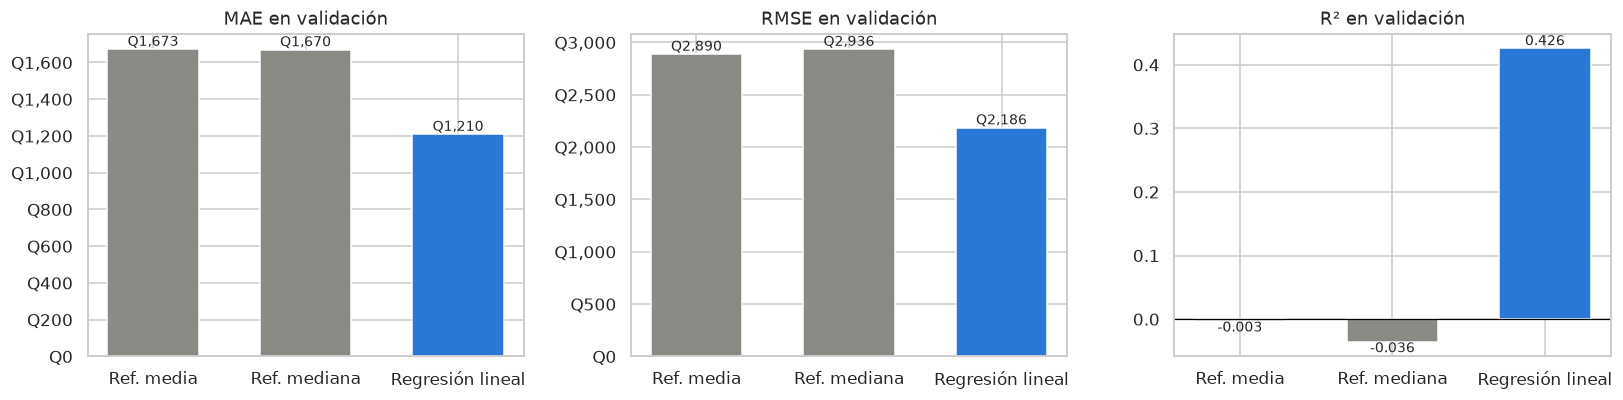

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
nombres = ["Ref. media", "Ref. mediana", "Regresión lineal"]
colores = [COLOR_REF, COLOR_REF, COLOR_LR]
for ax, m in zip(axes, ["MAE", "RMSE", "R²"]):
    vals = comparacion[m].values
    ax.bar(nombres, vals, color=colores, width=0.6)
    for i, v in enumerate(vals):
        ax.text(i, v, q(v) if m != "R²" else f"{v:.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
    ax.set_title(f"{m} en validación"); ax.axhline(0, color="black", lw=0.8)
    if m != "R²":
        ax.yaxis.set_major_formatter(fmt_q)
plt.tight_layout(); plt.show()

**Interpretación frente al modelo de referencia.** Se selecciona la regresión **sin regularización** (λ = 0, α = 0), que tiene el menor RMSE de validación. En IV de 2025:

* **MAE = Q1,210.** En promedio, la predicción se aleja Q1,210 del salario declarado: 28 % menos que la referencia (Q1,673). Sigue siendo un error considerable frente al salario mediano de validación (Q3,200), equivalente a un 38 % de él.
* **RMSE = Q2,186.** Es 24 % menor que el de la referencia. Que el RMSE casi duplique al MAE indica que el error está dominado por pocos casos con residuos grandes (sección 6).
* **R² = 0.426.** Los seis predictores explican cerca del 43 % de la variación del salario en validación. Es una mejora sustancial frente a la referencia (≈ 0), pero más de la mitad de la variación queda sin explicar: el salario depende también de factores que el modelo no observa, como la ocupación específica, la rama de actividad, el tamaño de la empresa o las habilidades.
* **No hay sobreajuste.** Las métricas de validación son incluso algo mejores que las de entrenamiento (RMSE Q2,186 frente a Q2,245). El entrenamiento contiene los salarios de Q99,000 (la misma persona en tres trimestres), que la recta no puede ajustar y que inflan su error; en validación, el máximo es Q60,000.

### 5.1 Coeficientes del modelo elegido

Como la estandarización es interna, los coeficientes están en las unidades originales: quetzales por año de edad o de antigüedad, por hora semanal, o diferencia en quetzales asociada a pertenecer a una categoría. Son asociaciones **condicionales** a las demás variables del modelo, no efectos causales.

Como el vector contiene **todas** las categorías de cada variable (sección 3), el nivel absoluto de cada coeficiente categórico no es interpretable por sí solo: sumar una constante a todas las categorías de una variable y restarla del intercepto produce las mismas predicciones. Lo que sí está determinado es la **diferencia entre categorías**. Por eso se expresan respecto a la categoría **más frecuente en entrenamiento** de cada variable (la de índice 0 del `StringIndexer`), que funciona como trabajador “típico” de referencia. Esta transformación no cambia ninguna predicción.

In [11]:
etiquetas = {}
for c, dc in zip(CATEGORICAS, DESCRIPCION):
    for fila in df.select(c, dc).distinct().collect():
        etiquetas[f"{c}_ohe_{fila[c]}"] = f"{c.replace('_', ' ')}: {fila[dc]}"

lr_final = modelo_lr.stages[-1]
coefs = pd.DataFrame({"variable": NOMBRES_FEATURES, "coeficiente": lr_final.coefficients.toArray()})
coefs["predictor"] = coefs["variable"].str.replace(r"_ohe_.*$", "", regex=True)
coefs["codigo"] = coefs["variable"].str.extract(r"_ohe_(.*)$")[0]
coefs["descripcion"] = coefs["variable"].map(etiquetas).fillna(coefs["variable"])

REFERENCIA_CAT = {c: modelo_lr.stages[i].labels[0] for i, c in enumerate(CATEGORICAS)}
coef_ref = {c: coefs.loc[(coefs.predictor == c) & (coefs.codigo == REFERENCIA_CAT[c]), "coeficiente"].iloc[0] for c in CATEGORICAS}
coefs["efecto_Q"] = np.where(coefs["predictor"].isin(CATEGORICAS),
                             coefs["coeficiente"] - coefs["predictor"].map(coef_ref), coefs["coeficiente"])
coefs["es_referencia"] = [p in CATEGORICAS and cod == REFERENCIA_CAT[p] for p, cod in zip(coefs.predictor, coefs.codigo)]
print("Categorías de referencia:", {c: etiquetas[f"{c}_ohe_{v}"] for c, v in REFERENCIA_CAT.items()})
print(f"Intercepto original: Q{lr_final.intercept:,.2f}")
print("\nPredictores numéricos (Q/mes por unidad adicional, manteniendo lo demás constante):")
display(coefs.loc[coefs.predictor.isin(NUMERICAS), ["variable", "efecto_Q"]].round(2))

Categorías de referencia: {'nivel_educativo': 'nivel educativo: DIVERSIFICADO', 'categoria_ocupacional': 'categoria ocupacional: Empleado de empresa privada', 'dominio': 'dominio: Urbano Metropolitano'}
Intercepto original: Q1,775.50

Predictores numéricos (Q/mes por unidad adicional, manteniendo lo demás constante):


,variable,efecto_Q
0,edad,20.43
1,antiguedad,23.37
2,horas_semanales,16.17


,descripcion,coeficiente,efecto_Q
14,categoria ocupacional: Del servicio doméstico,-1413.9,-1664.6
12,categoria ocupacional: Empleado jornalero o peón,-607.8,-858.5
13,categoria ocupacional: Empleado de gobierno,1424.3,1173.6
17,dominio: Rural Nacional,-218.7,-568.0
16,dominio: Resto Urbano,-209.3,-558.6
7,nivel educativo: NINGUNO,-1250.9,-1333.4
9,nivel educativo: PREPRIMARIA,-966.6,-1049.1
4,nivel educativo: PRIMARIA,-753.9,-836.4
5,nivel educativo: BÁSICO,-548.7,-631.2
6,nivel educativo: SUPERIOR,1776.9,1694.4


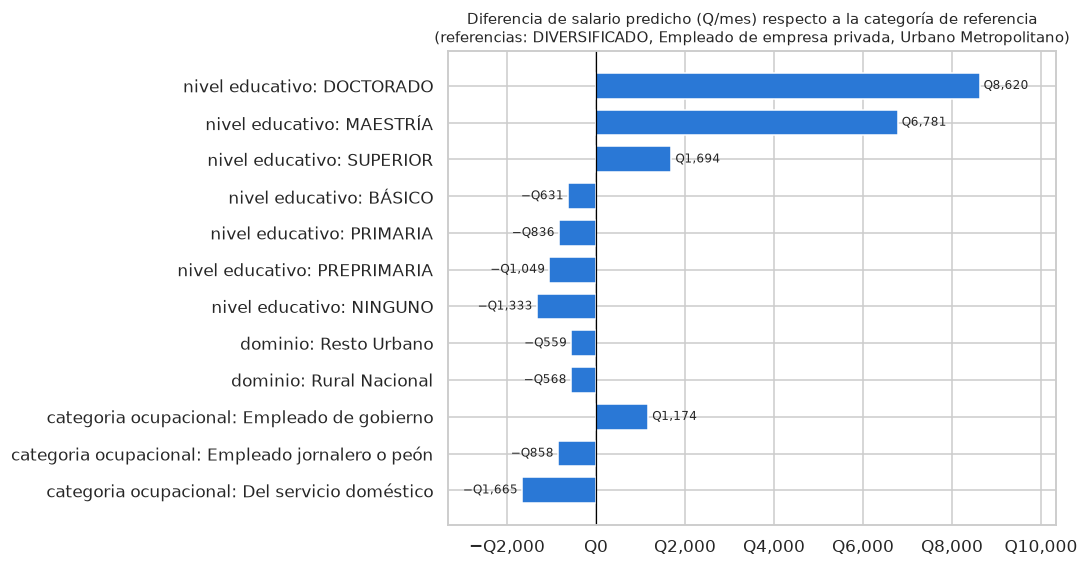

In [12]:
cat = coefs[coefs["predictor"].isin(CATEGORICAS) & ~coefs["es_referencia"]].copy()
cat = cat.sort_values(["predictor", "efecto_Q"])
display(cat[["descripcion", "coeficiente", "efecto_Q"]].round(1))

fig, ax = plt.subplots(figsize=(10, 0.36 * len(cat) + 1))
ax.barh(cat["descripcion"], cat["efecto_Q"], color=COLOR_LR, height=0.7)
ax.axvline(0, color="black", lw=0.8)
for i, v in enumerate(cat["efecto_Q"]):
    ax.text(v, i, f" {q(v)} ", va="center", ha="left" if v >= 0 else "right", fontsize=8)
ax.xaxis.set_major_formatter(fmt_q)
ref_txt = ", ".join(etiquetas[f"{c}_ohe_{v}"].split(": ")[1] for c, v in REFERENCIA_CAT.items())
ax.set_title(f"Diferencia de salario predicho (Q/mes) respecto a la categoría de referencia\n(referencias: {ref_txt})", fontsize=10)
ax.set_xlim(min(cat["efecto_Q"].min() * 2.0, 0), cat["efecto_Q"].max() * 1.2)
plt.tight_layout(); plt.show()

**Interpretación de los coeficientes** (asociaciones condicionales a las demás variables, no efectos causales):

* **Educación** es la variable con mayor efecto. Frente a diversificado, el modelo predice Q1,333 menos sin ningún nivel, Q836 menos con primaria y Q631 menos con básico; Q1,694 más con educación superior, Q6,781 más con maestría y Q8,620 más con doctorado. Este último se basa en unos 60 registros y es el menos preciso. El orden coincide con el de las medianas del notebook 02.
* **Categoría ocupacional.** Frente a empresa privada, ser empleado de gobierno se asocia con Q1,174 más; jornalero o peón, con Q858 menos; y servicio doméstico, con Q1,665 menos. Estas diferencias se mantienen al comparar personas con igual educación, edad, antigüedad, horas y dominio.
* **Dominio.** Resto urbano y rural nacional tienen salarios predichos unos Q560 menores que el área metropolitana, casi sin diferencia entre ellos.
* **Variables numéricas.** Cada año adicional de edad suma Q20; cada año de antigüedad, Q23; y cada hora semanal habitual, Q16. Son efectos pequeños por unidad, pero no despreciables en el rango observado: 20 años de antigüedad equivalen a unos Q470, y pasar de 40 a 60 horas, a unos Q320.
* **Limitación del modelo lineal.** Todos los efectos son **aditivos y constantes**. El notebook 02 mostró que el premio educativo es mucho mayor en gobierno que en servicio doméstico, y este modelo no puede representarlo sin términos de interacción. Tampoco puede capturar, por ejemplo, un efecto de la edad que crezca y luego se estabilice.

## 6. Influencia de los salarios extremos y de las personas repetidas

El enunciado pide conservar los salarios extremos en la evaluación principal y discutir su influencia. Las métricas de la sección 5 **ya los incluyen**. Aquí se descompone el error de validación por tramos del salario real, usando como cortes los percentiles 50, 90 y 99 del **entrenamiento**. El análisis completo de errores sobre 2026 corresponde al punto 8.

In [13]:
p50, p90, p99 = train.agg(F.expr(f"percentile({OBJETIVO}, array(0.5, 0.9, 0.99))")).first()[0]
TRAMOS = [f"1. ≤ p50 (≤ Q{p50:,.0f})", f"2. p50–p90 (Q{p50:,.0f}–{p90:,.0f}]", f"3. p90–p99 (Q{p90:,.0f}–{p99:,.0f}]", f"4. > p99 (> Q{p99:,.0f})"]

def tramo_salario(c=F.col(OBJETIVO)):
    return (F.when(c <= p50, TRAMOS[0]).when(c <= p90, TRAMOS[1]).when(c <= p99, TRAMOS[2]).otherwise(TRAMOS[3]))

def errores_por(pred, col_grupo):
    t = (pred.groupBy(col_grupo).agg(
            F.count("*").alias("n"),
            F.mean(OBJETIVO).alias("salario_medio"),
            F.mean("prediction").alias("prediccion_media"),
            F.mean(F.abs("residuo")).alias("MAE"),
            F.mean("residuo").alias("error_medio"),
            F.sum(F.col("residuo") ** 2).alias("sse"))
         .toPandas().sort_values(col_grupo).set_index(col_grupo))
    t["RMSE"] = np.sqrt(t["sse"] / t["n"])
    t["% registros"] = 100 * t["n"] / t["n"].sum()
    t["% del error cuadrático"] = 100 * t["sse"] / t["sse"].sum()
    return t.drop(columns="sse")

tabla_tramos = errores_por(pred_valid_lr.withColumn("tramo_salario", tramo_salario()), "tramo_salario")
display(tabla_tramos.round(1))

,n,salario_medio,prediccion_media,MAE,error_medio,RMSE,% registros,% del error cuadrático
tramo_salario,,,,,,,,
"1. ≤ p50 (≤ Q3,000)",6126,1836.3,2390.0,916.2,-553.6,1229.6,48.4,15.3
"2. p50–p90 (Q3,000–6,000]",5369,4075.5,4005.7,923.7,69.8,1281.7,42.4,14.6
"3. p90–p99 (Q6,000–15,000]",1079,8960.0,6098.2,3162.6,2861.8,3806.2,8.5,25.8
"4. > p99 (> Q15,000)",90,23223.4,8324.6,14898.7,14898.7,17264.5,0.7,44.3


In [14]:
# Sensibilidad (solo ilustrativa; NO sustituye a la evaluación principal): métricas sin los registros > p99 de entrenamiento
sin_p99 = pred_valid_lr.filter(F.col(OBJETIVO) <= p99)
sens = pd.DataFrame({"todos los registros (principal)": evaluar(pred_valid_lr),
                     f"sin salarios > Q{p99:,.0f} (sensibilidad)": evaluar(sin_p99)}).T
sens["n"] = [N_VALID, sin_p99.count()]
display(sens.round(3))

tabla_personas = errores_por(pred_valid_lr, "persona_en_train")
tabla_personas.index = tabla_personas.index.map({True: "persona vista en I–III 2025", False: "persona nueva en IV 2025"})
display(tabla_personas.round(1))

,mae,rmse,r2,n
todos los registros (principal),1210.137,2186.420,0.426,12664
"sin salarios > Q15,000 (sensibilidad)",1112.160,1637.446,0.469,12574


,n,salario_medio,prediccion_media,MAE,error_medio,RMSE,% registros,% del error cuadrático
persona_en_train,,,,,,,,
persona nueva en IV 2025,3833,3378.3,3291.7,1179.7,86.6,2188.5,30.3,30.3
persona vista en I–III 2025,8831,3616.7,3494.5,1223.3,122.3,2185.5,69.7,69.7


**Interpretación.**

* **Los salarios altos dominan el error cuadrático.** Los 90 registros de validación con salario mayor a Q15,000 (p99 de entrenamiento) son el 0.7 % del total, pero concentran el **44 %** de la suma de errores al cuadrado; el tramo p90–p99 aporta otro 26 %. Es decir, menos del 10 % de los registros genera el 70 % del error cuadrático.
* **Hay un sesgo sistemático según el nivel del salario.** El modelo **sobreestima** los salarios bajos (error medio de −Q554 en la mitad inferior) y **subestima** fuertemente los altos: +Q2,862 en el tramo p90–p99 y +Q14,899 por encima del p99, donde predice en promedio Q8,325 para salarios que promedian Q23,223. Es la regresión hacia la media propia de un modelo con R² moderado: las predicciones se concentran cerca del centro de la distribución.
* **Sensibilidad (solo ilustrativa).** Si se excluyeran los 90 salarios mayores a Q15,000, el RMSE bajaría de Q2,186 a Q1,637 y el R² subiría a 0.469. Esto muestra cuánto dependen las métricas cuadráticas de pocos casos. La evaluación principal los conserva, como pide el enunciado.
* **Personas repetidas.** El error es prácticamente igual para las personas ya vistas en entrenamiento (RMSE Q2,186) y para las nuevas (Q2,189). Con solo 18 coeficientes, la regresión lineal no puede “memorizar” individuos, así que la repetición del panel no infla su desempeño en validación.

## 7. Guardado del mejor modelo

Se guarda el `PipelineModel` completo (indexadores, codificador, ensamblador y regresión) ajustado con I–III de 2025, junto con un JSON que documenta la configuración elegida y sus métricas de validación. El punto 7 usará esa configuración para el entrenamiento final y evaluará sobre I de 2026, que no se ha leído en este notebook.

In [15]:
RUTA_LR = MODEL_DIR / "lr_mejor_pipeline"
modelo_lr.write().overwrite().save(str(RUTA_LR))

config_lr = {
    "algoritmo": "LinearRegression",
    "hiperparametros": {**MEJOR_CFG, "standardization": True, "fitIntercept": True, "maxIter": 200},
    "predictores": {"numericas": NUMERICAS, "categoricas": CATEGORICAS},
    "objetivo": OBJETIVO,
    "entrenamiento": {"periodos": PERIODOS_TRAIN, "registros": N_TRAIN},
    "validacion": {"periodo": PERIODO_VALID, "registros": N_VALID},
    "metricas_validacion": {m: float(mejor[f"{m}_valid"]) for m in METRICAS},
    "referencia_media_train": {"valor": float(media_train), **{m: float(ref_media[f"{m}_valid"]) for m in METRICAS}},
    "referencia_mediana_train": {"valor": float(mediana_train),
                                 **{m: float(tabla_ref.loc["Referencia: mediana de entrenamiento", f"{m}_valid"]) for m in METRICAS}},
    "configuraciones_probadas": CONFIGS_LR,
}
(MODEL_DIR / "lr_mejor_config.json").write_text(json.dumps(config_lr, ensure_ascii=False, indent=2))

# Verificación: el modelo cargado desde disco reproduce las métricas de validación
recargado = PipelineModel.load(str(RUTA_LR))
m_recargado = evaluar(recargado.transform(valid))
assert all(abs(m_recargado[m] - config_lr["metricas_validacion"][m]) < 1e-6 for m in METRICAS)
print("Modelo guardado en:", RUTA_LR)
print("Métricas de validación del modelo recargado:", {m: round(v, 4) for m, v in m_recargado.items()})

Modelo guardado en: /opt/app/working_dir/eneic_parquet/modelos/lr_mejor_pipeline
Métricas de validación del modelo recargado: {'mae': 1210.1375, 'rmse': 2186.4196, 'r2': 0.4257}


## Conclusiones del punto 5

1. Se construyó el pipeline `StringIndexer` → `OneHotEncoder` → `VectorAssembler` → `LinearRegression` (con estandarización interna), ajustado solo con I–III de 2025 y validado con IV de 2025.
2. Se probaron 13 configuraciones de regularización (λ ∈ {0, 1, 10, 100, 1000} y α ∈ {0, 0.5, 1}). La de menor RMSE de validación es **λ = 0** (sin penalización), prácticamente empatada con Ridge de λ pequeño. Con tanta información por coeficiente, la regularización no aporta, y con valores altos acerca el modelo a la referencia.
3. En validación, el modelo obtiene **MAE = Q1,210, RMSE = Q2,186 y R² = 0.426**, frente a MAE = Q1,673, RMSE = Q2,890 y R² ≈ 0 del modelo de referencia (reducciones de 28 % y 24 %).
4. La educación y la categoría ocupacional son los predictores con mayor asociación con el salario; edad, antigüedad y horas aportan efectos pequeños por unidad.
5. El error se concentra en los salarios altos, que el modelo subestima sistemáticamente, mientras que sobreestima los bajos. La forma lineal y aditiva no captura interacciones como educación × categoría ocupacional, lo que motiva probar un modelo no lineal (Random Forest, notebook 04).
6. El modelo se guardó en `working_dir/eneic_parquet/modelos/lr_mejor_pipeline` y su configuración en `lr_mejor_config.json`. I de 2026 no se ha utilizado.

In [16]:
spark.catalog.clearCache()